# Obtaining the cutouts of the plates

In [1]:
import json
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from collections import Counter
from tqdm import tqdm
import numpy as np
import random
import base64
import gzip
import requests
import os

## Let's do a quick EDA

In [2]:
with open("../Step_2_Integration/observability_bright.json", "r") as f:
    data = json.load(f)

In [3]:
print("There are",len(data.keys()),"MPC objects")

There are 16707 MPC objects


In [4]:
mpc_nums = np.sort(np.array(list(data.keys()), dtype=int))
photometric_summary = []
for num in tqdm(mpc_nums, desc="Processing MPCs"):
    subdata = np.asarray(data[str(num)])
    ra, dec, rearth, rsun, dradt, ddecdt, jd, platid, vmag = subdata.T
    vmag = vmag.astype(float)
    photometric_summary.append([num, len(vmag), np.mean(vmag), np.median(vmag), np.std(vmag)])
photometric_summary = np.array(photometric_summary)

Processing MPCs: 100%|██████████████████| 16707/16707 [00:16<00:00, 1029.55it/s]


## Number of Observations

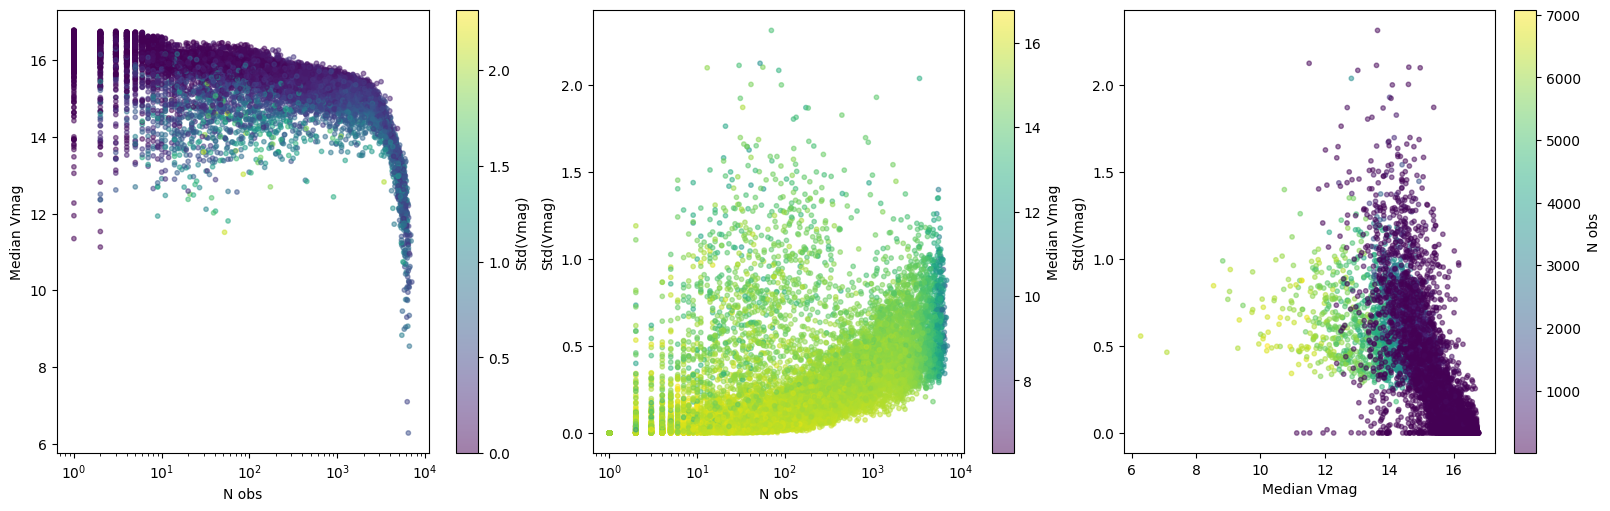

In [5]:
nobs = photometric_summary[:, 1].astype(int)
median = photometric_summary[:, 3].astype(float)
std = photometric_summary[:, 4].astype(float)

fig, ax = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

sc0 = ax[0].scatter(nobs, median, c=std, s=10, alpha=0.5, rasterized=True)
ax[0].set_xlabel("N obs")
ax[0].set_ylabel("Median Vmag")
ax[0].set_xscale("log")
fig.colorbar(sc0, ax=ax[0], label="Std(Vmag)")

sc1 = ax[1].scatter(nobs, std, c=median, s=10, alpha=0.5, rasterized=True)
ax[1].set_xlabel("N obs")
ax[1].set_ylabel("Std(Vmag)")
ax[1].set_xscale("log")
fig.colorbar(sc1, ax=ax[1], label="Median Vmag")

sc2 = ax[2].scatter(median, std, c=nobs, s=10, alpha=0.5, rasterized=True)
ax[2].set_xlabel("Median Vmag")
ax[2].set_ylabel("Std(Vmag)")
fig.colorbar(sc2, ax=ax[2], label="N obs")

plt.show()

## Distribution over Plates (most of the observations are on only 1-2 plates)

In [6]:
mpc_nums = np.sort(np.array(list(data.keys()), dtype=int))
platesolid_counts = Counter()
for num in tqdm(mpc_nums, desc="Processing MPCs"):
    subdata = np.asarray(data[str(num)])
    platesolid = subdata[:, 7]

    unique_ids, counts = np.unique(platesolid, return_counts=True)
    platesolid_counts.update(dict(zip(unique_ids, counts)))

Processing MPCs: 100%|███████████████████| 16707/16707 [00:22<00:00, 734.07it/s]


In [7]:
print("A total of ",len(platesolid_counts)," Plates appear asteroids") 
#this is a ~30% of the total! it's not neglibigle

A total of  248675  Plates appear asteroids


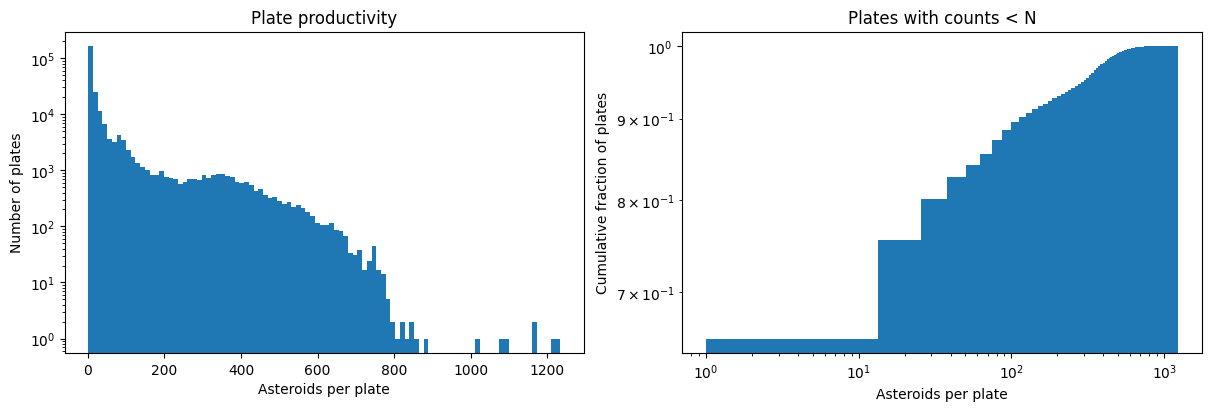

In [8]:
counts = np.array(list(platesolid_counts.values()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax[0].hist(counts, bins=100)
ax[0].set_yscale("log")
ax[0].set_xlabel("Asteroids per plate")
ax[0].set_ylabel("Number of plates")
ax[0].set_title("Plate productivity")

ax[1].hist(counts, bins=100, cumulative=True, density=True)
ax[1].set_xlabel("Asteroids per plate")
ax[1].set_ylabel("Cumulative fraction of plates")
ax[1].set_title("Plates with counts < N")
ax[1].set_yscale("log")
ax[1].set_xscale("log")

plt.show()
# #most plates will ahve onlt a few asteroids, though a few are hyperproductive!


## Virtual distribution

In [9]:
vmag_edges = np.arange(8, 18 + 0.25, 0.25)
vmag_bin_counts_arr = np.zeros(len(vmag_edges) - 1, dtype=int)

mpc_nums = np.sort(np.array(list(data.keys()), dtype=int))

for num in tqdm(mpc_nums, desc="Processing MPCs"):
    subdata = np.asarray(data[str(num)])
    vmag = subdata[:, 8].astype(float)

    counts, _ = np.histogram(vmag, bins=vmag_edges)
    vmag_bin_counts_arr += counts

vmag_bin_counts = Counter(dict(enumerate(vmag_bin_counts_arr)))

Processing MPCs: 100%|███████████████████| 16707/16707 [00:19<00:00, 865.43it/s]


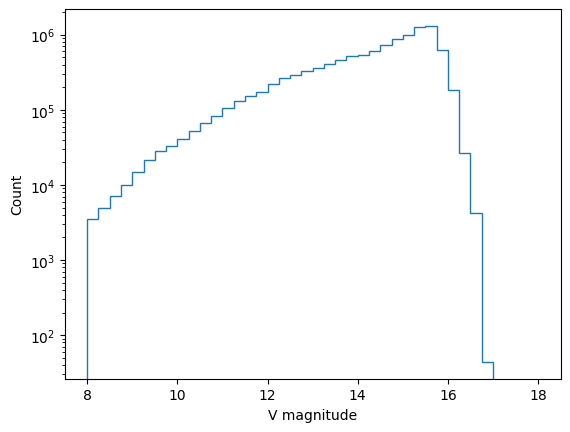

In [10]:
vmag_counts = np.array([vmag_bin_counts.get(i, 0) for i in range(len(vmag_edges) - 1)], dtype=np.int64)

plt.figure()
plt.stairs(vmag_counts, vmag_edges)
plt.xlabel("V magnitude")
plt.ylabel("Count")
plt.yscale("log")  # optional, probably useful here
plt.show()

## Are there any good asteroids?

In [11]:
targets = np.arange(6, 21)

for mag in targets:
    mask = photometric_summary[:,1] >= 1000
    rows = photometric_summary[mask]

    score = ((rows[:,3] - mag)/0.25)**2 + (rows[:,4]/0.05)**2

    best = rows[np.argmin(score)]

    print(
        f"{mag:2d}: MPC {int(best[0]):7d} "
        f"median={best[3]:.3f} "
        f"std={best[4]:.4f} "
        f"nobs={int(best[1])}"
    )

 6: MPC       1 median=7.093 std=0.4638 nobs=6263
 7: MPC       1 median=7.093 std=0.4638 nobs=6263
 8: MPC       1 median=7.093 std=0.4638 nobs=6263
 9: MPC      29 median=9.297 std=0.4871 nobs=6195
10: MPC     196 median=10.963 std=0.3421 nobs=6619
11: MPC     196 median=10.963 std=0.3421 nobs=6619
12: MPC     702 median=11.866 std=0.3255 nobs=5699
13: MPC     420 median=13.155 std=0.2898 nobs=5654
14: MPC     624 median=14.215 std=0.1802 nobs=4856
15: MPC    4709 median=15.435 std=0.1365 nobs=2329
16: MPC    3978 median=15.711 std=0.1013 nobs=1014
17: MPC    3978 median=15.711 std=0.1013 nobs=1014
18: MPC   15436 median=15.788 std=0.1428 nobs=1064
19: MPC   15436 median=15.788 std=0.1428 nobs=1064
20: MPC   15436 median=15.788 std=0.1428 nobs=1064


In [12]:
mpc_ids = [1, 29, 196, 702, 420, 624, 4709, 3978, 15436]

## Finding good examples

In [20]:
rng = np.random.default_rng(42)

mpc_nums = np.array(list(data.keys()), dtype=int)
n_sample = 5000

sampled_rows = []

for _ in tqdm(range(n_sample), desc="Sampling rows"):
    num = rng.choice(mpc_nums)

    subdata = np.asarray(data[str(num)])
    row_idx = rng.integers(len(subdata))
    row = subdata[row_idx]

    sampled_rows.append(np.concatenate([[num], row]))

sampled_rows = np.array(sampled_rows)
mpc_num,ra,dec,rearth,rsun,dradt,ddecdt,jd,platesolid,vmag = sampled_rows.T

Sampling rows: 100%|██████████████████████| 5000/5000 [00:03<00:00, 1392.35it/s]


In [21]:
from daschlab import open_session
from pathlib import Path
import os

In [22]:
path = './filter_check/'
#os.mkdir('./filter_check')#

In [23]:
log = []
for i in tqdm(range(100)):    
    plateid, solnum = platesolid[i].split(':')
    plate_series = ''.join(c for c in plateid if c.isalpha())
    plate_num = ''.join(c for c in plateid if c.isdigit())

    session_dir = path+"dasch_"+str(mpc_num[i])
    sess = (open_session(session_dir).select_target(ra_deg=float(ra[i]), dec_deg=float(dec[i])).select_refcat("apass"))
    exps = sess.exposures()
    hits = exps[(exps["series"] == plate_series) & (exps["platenum"] == int(plate_num)) & (exps["solnum"] == int(solnum))]
    if len(hits) == 0:
        row = [i, plateid, solnum, np.nan, np.nan, np.nan, np.nan]
    else:
        hit = hits[0]
        row = [i, plateid, solnum, hit["center_distance"], hit["edge_distance"], hit["lim_mag_apass"], hit["lim_mag_atlas"],float(vmag[i])]

    log.append(row)

  0%|                                                   | 0/100 [00:00<?, ?it/s]WARNING: AstropyDeprecationWarning: Importing ErfaWarning from astropy.utils.exceptions was deprecated in version 6.1 and will stop working in a future version. Instead, please use
from erfa import ErfaWarning

 [astropy.utils.exceptions]
  1%|▍                                          | 1/100 [00:00<00:13,  7.40it/s]

Opened DASCH session at disk location `filter_check/dasch_12836`
- Query target: `11:21:40.6 +5:38:46
- Refcat: 206 sources from `apass`
- Exposures: 10977 relevant exposures
Opened DASCH session at disk location `filter_check/dasch_45953`
- Query target: `9:45:10.3 +23:49:05
- Refcat: 433 sources from `apass`


  3%|█▎                                         | 3/100 [00:00<00:15,  6.40it/s]

- Exposures: 13329 relevant exposures
Opened DASCH session at disk location `filter_check/dasch_2887`
- Query target: `0:04:12.7 -6:44:31
- Refcat: 231 sources from `apass`
- Exposures: 13460 relevant exposures
Opened DASCH session at disk location `filter_check/dasch_1273`
- Query target: `1:00:01.4 +17:36:46
- Refcat: 367 sources from `apass`


  5%|██▏                                        | 5/100 [00:00<00:15,  6.22it/s]

...

- Exposures: 9889 relevant exposures
Opened DASCH session at disk location `filter_check/dasch_18369`
- Query target: `20:49:41.9 -29:24:50
- Refcat: 635 sources from `apass`


 99%|█████████████████████████████████████████▌| 99/100 [00:17<00:00,  7.50it/s]

- Exposures: 8447 relevant exposures
Opened DASCH session at disk location `filter_check/dasch_48590`
- Query target: `8:18:57.5 +41:47:20
- Refcat: 375 sources from `apass`


100%|█████████████████████████████████████████| 100/100 [00:17<00:00,  5.58it/s]

- Exposures: 14715 relevant exposures


In [24]:
log

[[0, 'ai44495', '0', 3.8, 8.4, masked, masked, 16.589729705688367],
 [1, 'ai44199', '0', 6.5, 3.3, masked, masked, 16.438040139947866],
 [2, 'ka02011', '0', 10.2, 2.0, masked, masked, 15.20297027059026],
 [3, 'ai41307', '0', 5.0, 5.8, masked, masked, 14.59895540122897],
 [4, 'ai08315', '0', 12.5, 1.1, masked, masked, 13.910963522788622],
 [5, 'ai44484', '0', 6.6, 3.1, masked, masked, 16.347324653176305],
 [6, 'mf40855', '0', 7.7, 5.4, 17.269, 17.238, 16.35572289789244],
 [7, 'ai44514', '0', 8.8, 4.3, masked, masked, 16.02836270064119],
 [8, 'fa08796', '0', 3.1, 8.9, 11.681, 11.646, 15.317154190447571],
 [9, 'ai44514', '0', 12.0, 0.7, masked, masked, 15.462782329201586],
 [10, 'bi04059', '0', 5.7, 5.1, masked, masked, 15.078476568408949],
 [11, 'fa07803', '0', 10.0, 0.8, masked, masked, 14.553812964999857],
 [12, 'bi01529', '0', 10.2, 3.1, masked, masked, 15.479093223238705],
 [13, 'bi03675', '0', 10.8, 1.4, masked, masked, 15.823602368280978],
 [14, 'ai39921', '0', 11.1, 1.3, masked, m

In [27]:
log = np.array(log, dtype=object)

limits = np.array(log[:, 5:7], dtype=float)   # masked -> nan
predvmags = log[:, 7].astype(float)

# row is unconstrained if both limit columns are nan
row_masked = ~np.isfinite(limits).any(axis=1)
frac_masked = row_masked.mean()
valid = ~row_masked

# conservative = shallower/brighter limit = min finite value
conservative_limiting_mag = np.nanmin(limits[valid], axis=1)

passes = conservative_limiting_mag > predvmags[valid]
frac_pass_unmasked = passes.mean()

print(f"Fraction masked/unconstrained: {frac_masked:.2%}")
print(f"Among unmasked, fraction with limit > predicted Vmag: {frac_pass_unmasked:.2%}")
print(f"N unmasked: {valid.sum()} / {len(log)}")
print(f"N pass among unmasked: {passes.sum()} / {valid.sum()}")

Fraction masked/unconstrained: 68.00%
Among unmasked, fraction with limit > predicted Vmag: 18.75%
N unmasked: 32 / 100
N pass among unmasked: 6 / 32


/tmp/ipykernel_65748/2427967164.py:3: UserWarning: Warning: converting a masked element to nan.
  limits = np.array(log[:, 5:7], dtype=float)   # masked -> nan
